In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import HDBSCAN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px

In [3]:
from matplotlib.colors import XKCD_COLORS

In [4]:
fdf = pd.read_csv("./full_fef_dataset2.csv", header=0, index_col=0)
fdf.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v113,v114,v115,v116,v117,v118,v119,target,indoor,outdoor
0,0.0,-0.000021,0.000011,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,-0.000022,-0.000032,0.000021,0.000010,-0.000072,0.000000,-0.000009,0.0,0.0,0.0
1,2.2,-0.000021,0.000021,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,-0.000022,-0.000032,0.000021,0.000010,-0.000072,0.000000,0.000000,0.0,0.0,0.0
2,4.4,-0.000031,0.000011,0.00001,0.000010,-0.000011,-0.000011,-0.000009,0.00001,0.000043,...,-0.000022,-0.000032,0.000021,0.000000,-0.000072,0.000000,-0.000018,0.0,0.0,0.0
3,6.6,-0.000021,0.000021,0.00000,-0.000010,0.000011,0.000011,0.000000,0.00001,0.000011,...,-0.000011,-0.000032,0.000010,0.000019,-0.000072,0.000010,0.000026,0.0,0.0,0.0
4,8.8,-0.000042,0.000000,0.00002,0.000031,-0.000033,-0.000021,-0.000019,0.00002,0.000074,...,-0.000032,-0.000032,0.000031,-0.000019,-0.000072,-0.000019,-0.000061,0.0,0.0,0.0


In [7]:
x = fdf.drop(['target', 'indoor', 'outdoor', 'scan_time'], axis=1)
x_norm = StandardScaler().fit_transform(x)
y = fdf[['indoor', 'outdoor']]

In [8]:
pca = PCA()
pca_x_norm = pca.fit_transform(x)

In [9]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

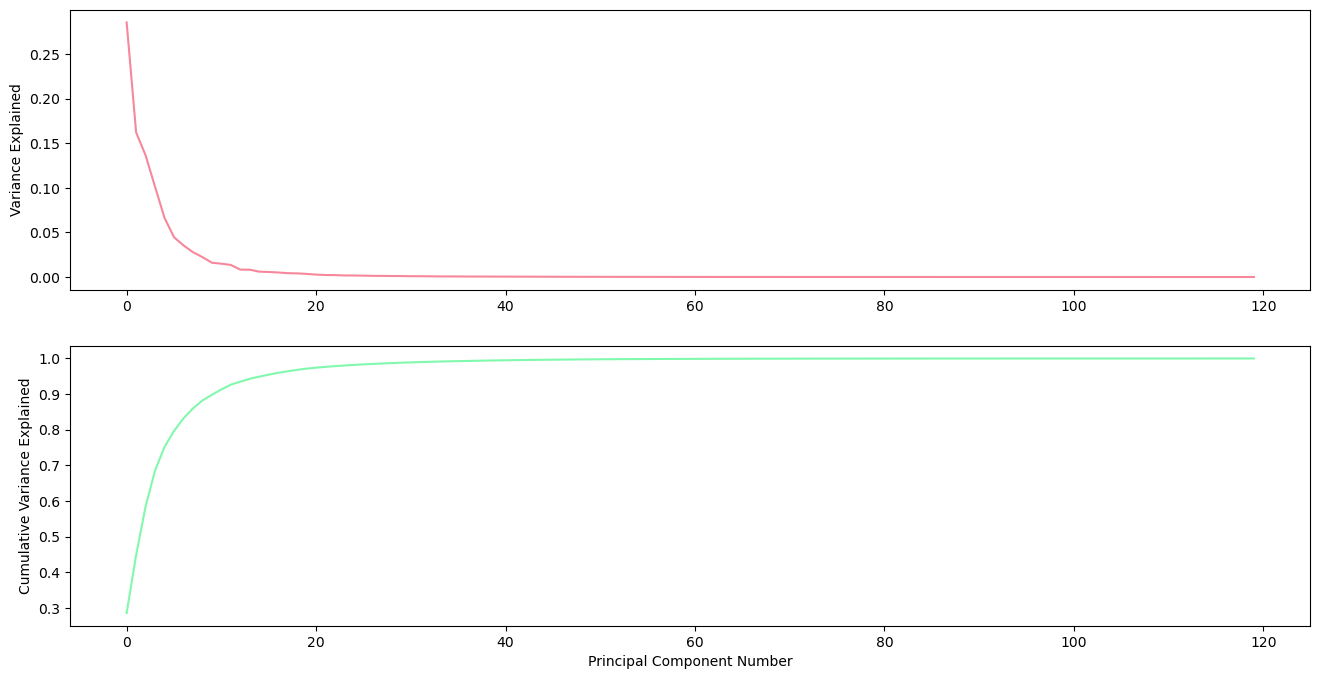

In [10]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

Okay, before moving on to more modeling, let's just take a moment to see if our data actually contain the information we are looking for. We'll do unsupervised learning to get a sense of how separable our data are.

In [13]:
hdb = HDBSCAN(copy=True, min_cluster_size=200)
hdb.fit(x)

,min_cluster_size,200
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [17]:
hdb = HDBSCAN(copy=True, min_cluster_size=20)
hdb.fit(pca_x_norm[:,0:15])

,min_cluster_size,20
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


Now, this is pretty meaningless to us without an actual visualization, so let's t-sne our way into 3 dimensions so we can take a look.  Before that, let's find out how many labels we even have.

In [18]:
np.unique(hdb.labels_).tolist()

[-1,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110]

In [29]:
separate_runs = []
counter = 0
for i in range(fdf.shape[0]-1):
    if fdf['scan_time'].loc[i]<fdf['scan_time'].loc[i+1]:
        counter += 1
    separate_runs.append(counter)
separate_runs.append(counter)


In [30]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(pca_x_norm[:,0:15])
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = fdf['scan_time']
tsne_df['Labels'] = hdb.labels_
tsne_df['Runs'] = separate_runs

In [31]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Runs', opacity=0.7, size_max=3, title="3D t-SNE of Brain States")
fig.show(renderer="iframe")

Here, we see that the strands might actually reflect the individual runs. I've created a new csv containing the data we were using along with columns for subject, session, and overall run numbers. We will clone this notebook and run the same code on the new csv file.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(pca_x_norm[:,0:15], y, test_size=0.3, random_state=42)